# Part 3: Model Evaluation & Systematic Error Analysis

This notebook evaluates the final trained models on the test set, performs error analysis, and quantifies prediction uncertainty:
1. **Model Performance Comparison**: Compare Linear Regression, XGBoost, Random Forest, and the Weighted Ensemble.
2. **Visualizations**: Plot Actual vs Predicted scatter and residual distributions.
3. **Systematic Error Analysis**: Examine errors across life stages (Critical, Warning, Healthy).
4. **Uncertainty Quantification**: Calculate 95% confidence intervals for predictions based on local error standard deviations.
5. **Model Interpretability (SHAP)**: Explain predictions globally.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap

# Configure styles
sns.set_theme(style="whitegrid", font_scale=1.1)
DATA_DIR = r"../data"
MODEL_DIR = r"../models"
FIGURE_DIR = r"../figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIGURE_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

C:\Users\21779\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.1 Load Data and Model Pipeline

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "SmartFactory_FD002_features.csv"))
model_bundle = joblib.load(os.path.join(MODEL_DIR, "final_model.pkl"))
selected_features = model_bundle['selected_features']
scaler = joblib.load(r"../config/scaler.pkl")

# Recalculate Engine-wise Split identically
unique_engines = df['Engine_ID'].unique()
np.random.seed(42)
np.random.shuffle(unique_engines)
split_idx = int(len(unique_engines) * 0.8)
test_engines = unique_engines[split_idx:]

df_test = df[df['Engine_ID'].isin(test_engines)].copy()
X_test = df_test[selected_features]
y_test = df_test['RUL_capped']

print(f"Loaded {len(df_test)} test samples from {len(test_engines)} engines.")

Loaded 10870 test samples from 52 engines.


## 3.2 Predictions & Performance Comparison Table

In [3]:
lr = model_bundle['model_lr']
xgb_m = model_bundle['model_xgb']
rf = model_bundle['model_rf']
weights = model_bundle['weights']
w_xgb, w_rf = weights['xgb'], weights['rf']

# Scale features for LR
X_test_scaled = scaler.transform(X_test)

# Predict
lr_preds = lr.predict(X_test_scaled)
xgb_preds = xgb_m.predict(X_test)
rf_preds = rf.predict(X_test)
ensemble_preds = w_xgb * xgb_preds + w_rf * rf_preds

models = {
    'Linear Regression': lr_preds,
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds,
    'Weighted Ensemble': ensemble_preds
}

metrics = {}
for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics[name] = [mae, rmse, r2]

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['MAE', 'RMSE', 'R2'])
print(metrics_df)
metrics_df.to_csv(os.path.join(FIGURE_DIR, "Model_Comparison.csv"))

                         MAE       RMSE        R2
Linear Regression  20.360951  25.155989  0.634779
Random Forest      19.747592  27.707197  0.556945
XGBoost            19.178833  26.602049  0.591584
Weighted Ensemble  19.282004  26.893191  0.582595


## 3.3 Visualizing Performance (Scatter Plot & Residuals)

Saved: ../figures\Actual_vs_Predicted_Scatter.png


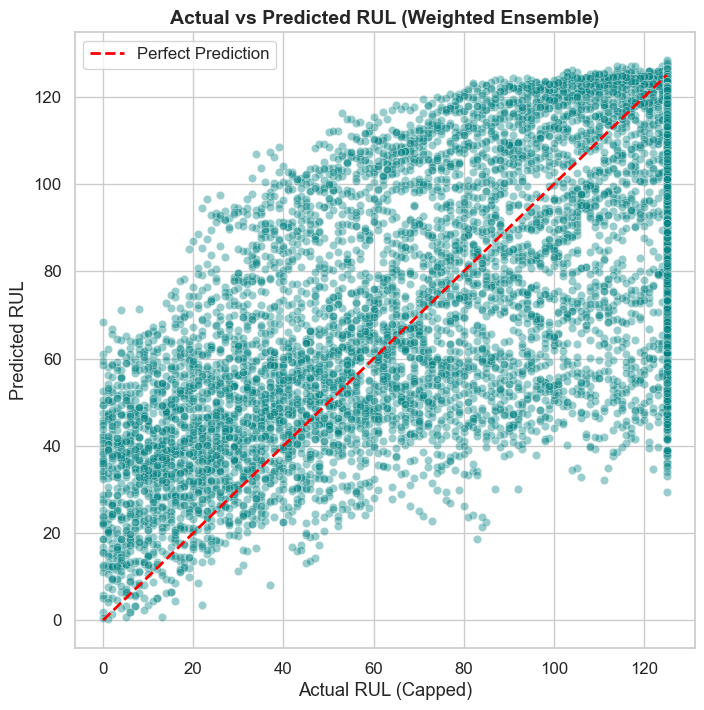

Saved: ../figures\Residual_Distribution.png


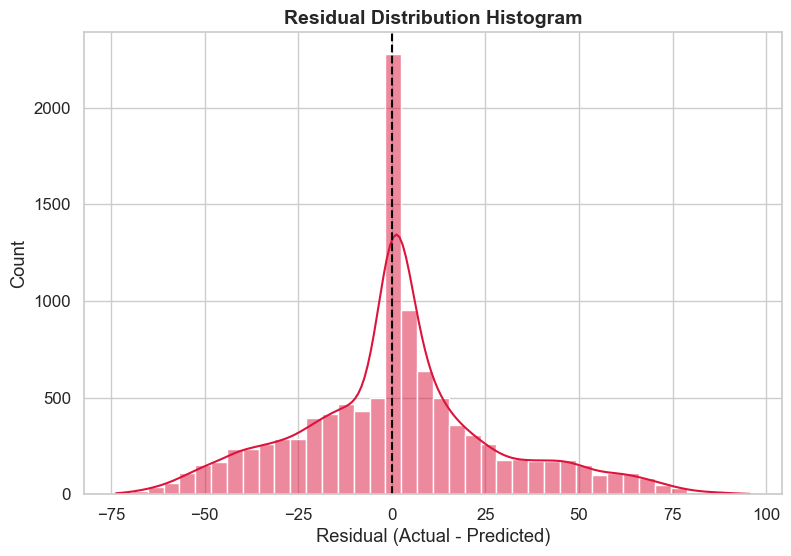

In [4]:
df_test['preds'] = ensemble_preds
df_test['residual'] = df_test['RUL_capped'] - df_test['preds']

# 1. Scatter Plot
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=df_test['RUL_capped'], y=df_test['preds'], alpha=0.4, color='teal', ax=ax)
ax.plot([0, 125], [0, 125], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_title("Actual vs Predicted RUL (Weighted Ensemble)", fontsize=14, fontweight='bold')
ax.set_xlabel("Actual RUL (Capped)")
ax.set_ylabel("Predicted RUL")
ax.legend()
save_fig(fig, "Actual_vs_Predicted_Scatter.png")
plt.show()

# 2. Residual Distribution
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df_test['residual'], kde=True, color='crimson', bins=40, ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title("Residual Distribution Histogram", fontsize=14, fontweight='bold')
ax.set_xlabel("Residual (Actual - Predicted)")
save_fig(fig, "Residual_Distribution.png")
plt.show()

## 3.4 Systematic Error Analysis by RUL intervals

Systematic Residuals Statistics by RUL Range:
        RUL_interval       mean        std  count
0   Critical (0-45) -23.001207  19.027698   2392
1   Warning (45-80)  -8.205672  24.185186   1820
2  Healthy (80-125)  12.820337  22.763988   6658


C:\Users\21779\AppData\Local\Temp\ipykernel_20680\1820992428.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x='RUL_interval', y='residual', ax=ax, palette="Set2")


Saved: ../figures\Systematic_Error_Boxplot.png


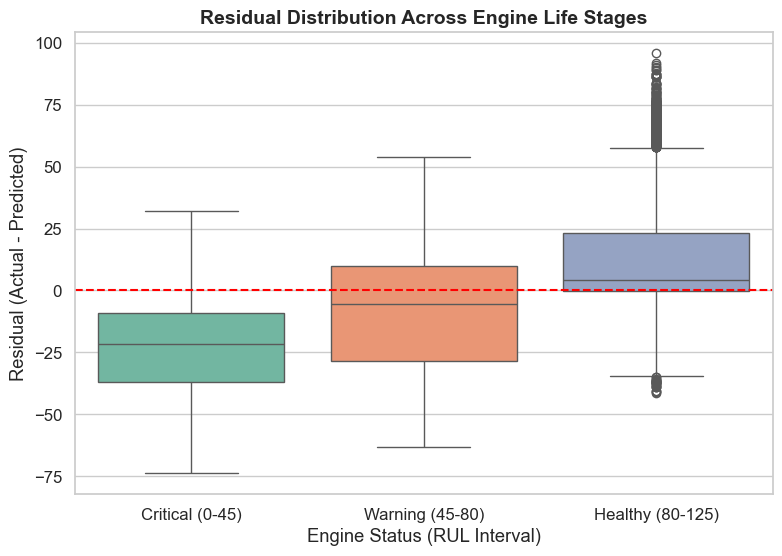

In [5]:
df_test['RUL_interval'] = pd.cut(
    df_test['RUL_capped'], 
    bins=[0, 45, 80, 125], 
    labels=['Critical (0-45)', 'Warning (45-80)', 'Healthy (80-125)'], 
    include_lowest=True
)

grouped_errors = df_test.groupby('RUL_interval', observed=False)['residual'].agg(['mean', 'std', 'count']).reset_index()
print("Systematic Residuals Statistics by RUL Range:\n", grouped_errors)

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df_test, x='RUL_interval', y='residual', ax=ax, palette="Set2")
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title("Residual Distribution Across Engine Life Stages", fontsize=14, fontweight='bold')
ax.set_xlabel("Engine Status (RUL Interval)")
ax.set_ylabel("Residual (Actual - Predicted)")
save_fig(fig, "Systematic_Error_Boxplot.png")
plt.show()

## 3.5 Model Interpretability with SHAP

C:\Users\21779\AppData\Local\Temp\ipykernel_20680\766035322.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, show=False)


Saved: ../figures\SHAP_Summary_Plot.png


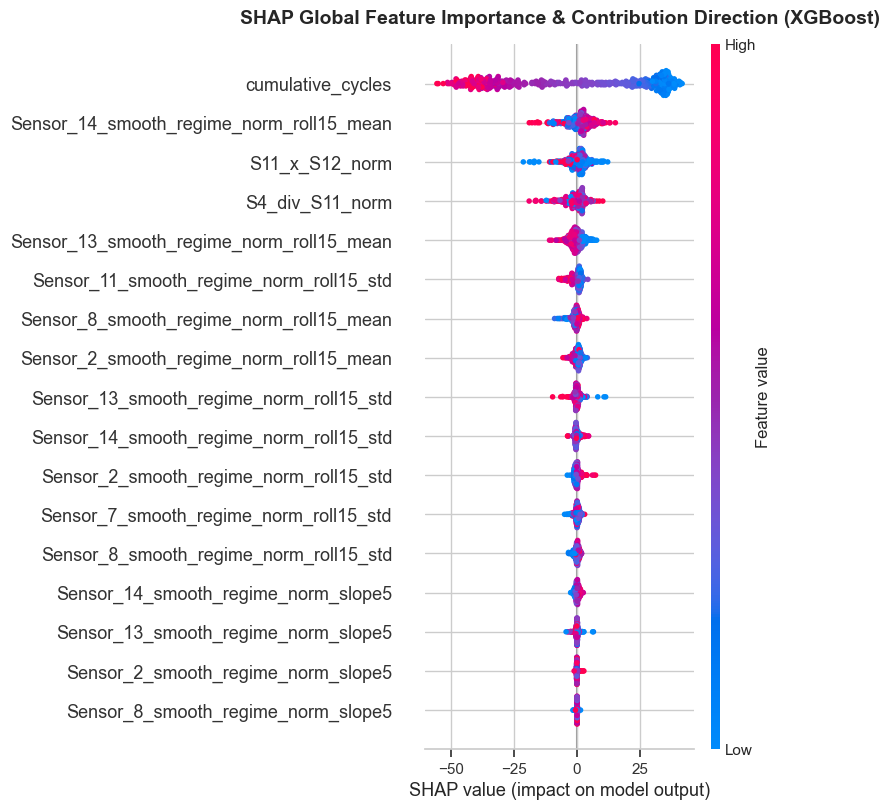

['../models\\interval_stds.pkl']

In [6]:
explainer = shap.TreeExplainer(xgb_m)
shap_sample = X_test.sample(500, random_state=42)
shap_values = explainer(shap_sample)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Global Feature Importance & Contribution Direction (XGBoost)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_fig(fig, "SHAP_Summary_Plot.png")
plt.show()

# Save interval stds for confidence intervals in dashboard
interval_stds = dict(zip(grouped_errors['RUL_interval'].astype(str), grouped_errors['std']))
joblib.dump(interval_stds, os.path.join(MODEL_DIR, "interval_stds.pkl"))